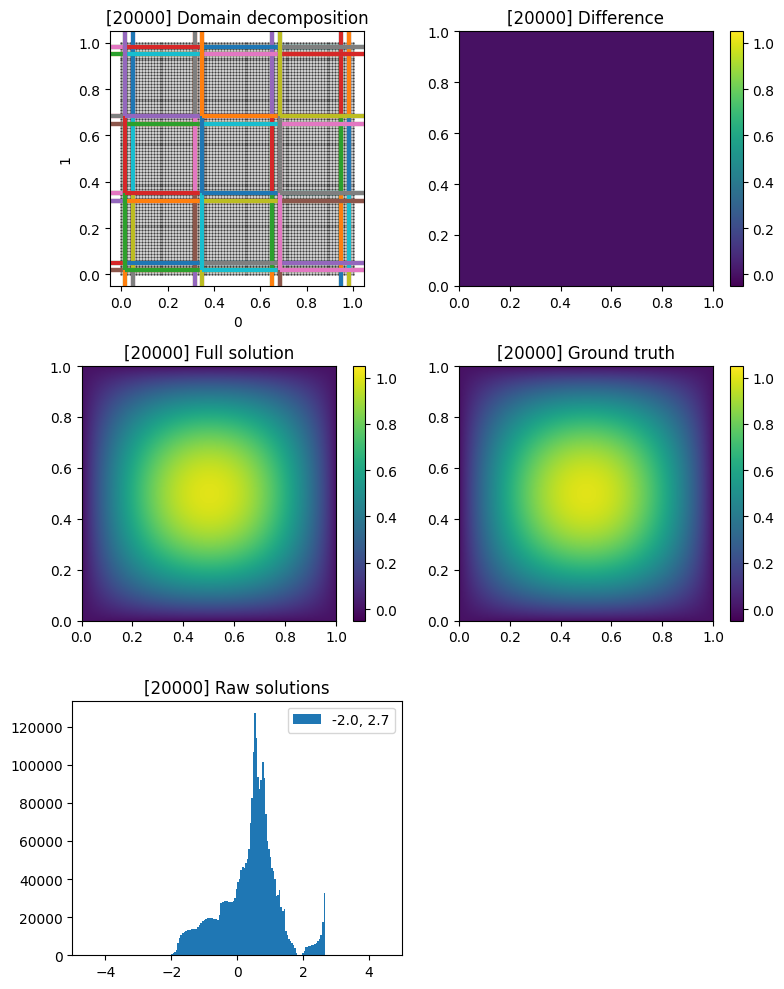

[INFO] 2026-03-12 12:01:02 - [i: 20000/20000] Training complete


In [1]:
import numpy as np
import jax.numpy as jnp

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import Problem
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.constants import Constants

domain = RectangularDomainND

domain_init_kwargs = dict(
    xmin=np.array([0.,0.]),
    xmax=np.array([1.,1.]),
)

class HomogeneousLaplacian2D(Problem):

    @staticmethod
    def init_params(sigma=0.2):
    
        static_params = {
            "dims": (1, 2),
            "sigma": sigma,
        }
    
        return static_params, {}

    @staticmethod
    def sample_constraints(all_params, domain, key, sampler, batch_shapes):

        x_batch_phys = domain.sample_interior(all_params, key, sampler, batch_shapes[0])

        required_ujs_phys = (
            (0, ()),
            (0, (0, 0)),
            (0, (1, 1)),
        )

        return [[x_batch_phys, required_ujs_phys]]

    @staticmethod
    def loss_fn(all_params, constraints):

        x_batch, u, u_xx, u_yy = constraints[0]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        f = 32.0 * (x * (1.0 - x) + y * (1.0 - y))

        phys = jnp.mean((-u_xx - u_yy - f) ** 2)

        return phys

    @staticmethod
    def constraining_fn(all_params, x_batch, u):

        sigma = all_params["static"]["problem"]["sigma"]

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        c = (
            jnp.tanh(x / sigma)
            * jnp.tanh((1.0 - x) / sigma)
            * jnp.tanh(y / sigma)
            * jnp.tanh((1.0 - y) / sigma)
        )

        return c * u

    @staticmethod
    def exact_solution(all_params, x_batch, batch_shape=None):

        x = x_batch[:, 0:1]
        y = x_batch[:, 1:2]

        return 16.0 * x * (1.0 - x) * y * (1.0 - y)


problem = HomogeneousLaplacian2D
problem_init_kwargs = dict(
    sigma=0.2,
)

delta = 1.9

level_1 = np.array([0.5])
level_2 = np.array([0.0, 1.0])
level_3 = np.array([0.0, 1.0/3.0, 2.0/3.0, 1.0])

w1 = np.array([1.9])
w2 = np.array([1.9, 1.9])
w3 = np.array([1.9/3.0, 1.9/3.0, 1.9/3.0, 1.9/3.0])

xs_all = np.concatenate([level_1, level_2, level_3])
ws_all = np.concatenate([w1, w2, w3])

decomposition = RectangularDecompositionND
decomposition_init_kwargs = dict(
    subdomain_xs=[xs_all, xs_all],
    subdomain_ws=[ws_all, ws_all],
    unnorm=(0.0, 1.0),
)

network = FCN
network_init_kwargs = dict(
    layer_sizes=[2, 16, 1],
)

c = Constants(
    domain=domain,
    domain_init_kwargs=domain_init_kwargs,
    problem=problem,
    problem_init_kwargs=problem_init_kwargs,
    decomposition=decomposition,
    decomposition_init_kwargs=decomposition_init_kwargs,
    network=network,
    network_init_kwargs=network_init_kwargs,
    ns=((80,80),),
    n_test=(350, 350),
    n_steps=20000,
    clear_output=True,
)

print(c)

from fbpinns.trainers import FBPINNTrainer

loss_history = []

run = FBPINNTrainer(c)
all_params = run.train()

In [2]:
1+1

2